# Bank Customer Churn Prediction

## Project Overview

This project uses machine learning to predict whether a bank customer is
likely to churn based on demographic, financial and account-related
characteristics.

Several classification models are developed and compared, including Logistic
Regression, Decision Tree and Random Forest. Hyperparameter tuning is then
applied to the Random Forest model to identify an optimized model.


In [1]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [2]:
local_path = "../data/Bank Customer Churn Prediction.csv"
colab_path = "/content/Bank Customer Churn Prediction.csv"

if os.path.exists(local_path):
    data_path = local_path
else:
    data_path = colab_path

df = pd.read_csv(data_path)

print(f"Dataset loaded from: {data_path}")
print(f"Dataset shape: {df.shape}")

Dataset loaded from: /content/Bank Customer Churn Prediction.csv
Dataset shape: (10000, 12)


In [3]:
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df.shape

(10000, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [ ]:
df.describe()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [ ]:
df.isnull().sum()

,0
customer_id,0
credit_score,0
country,0
gender,0
age,0
tenure,0
balance,0
products_number,0
credit_card,0
active_member,0


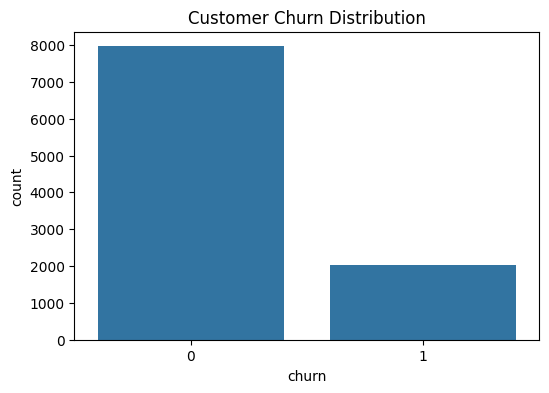

In [ ]:
# Exploratory Data Analysis(EDA)

plt.figure(figsize=(6,4))
sns.countplot(x='churn', data=df)

plt.title("Customer Churn Distribution")
plt.show()

In [ ]:
df.columns

Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
       'balance', 'products_number', 'credit_card', 'active_member',
       'estimated_salary', 'churn'],
      dtype='object')

In [ ]:
df = df.drop('customer_id', axis=1)
df.head()

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df['churn'].value_counts()

,count
churn,
0,7963
1,2037


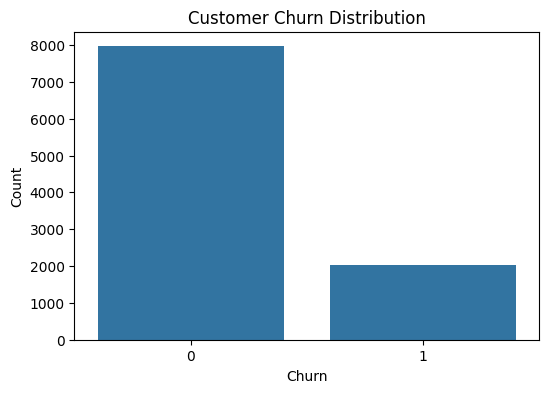

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='churn', data=df)
plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.savefig('churn_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
print(os.listdir())

['.config', 'drive', 'Bank Customer Churn Prediction.csv', 'churn_distribution.png', 'sample_data']


In [ ]:
from google.colab import files

files.download('churn_distribution.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
churn_rate = df['churn'].mean() * 100
print(f'Churn Rate: {churn_rate:.2f}%')

Churn Rate: 20.37%


# Interpretation

The churn rate represents the percentage of customers who left the bank.
It helps determine whether the dataset is balanced.


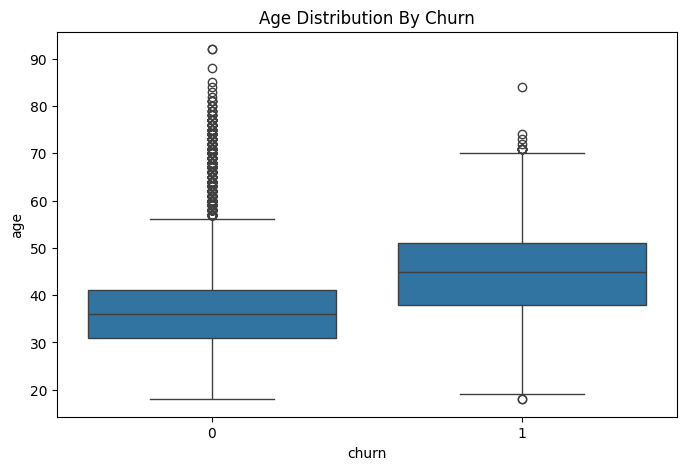

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='churn', y='age', data=df)
plt.title("Age Distribution By Churn")
plt.show()

#Interpretation

##Shifted Medians
Non-churned customers(0): The median age is roughly 36 years old.
Churned customers(1): The median age is roughly 46 years old (showing a 10 year upward shift).

##Differing Age Spreads
Active group(0): The middle 50% of users fall between 32 and 41 years old.
Churned group(1): The middle 50% spans wider, ranging from roughly 39 to 52 years old.

##Outlier Distinctions
Active group(0): Possesses a massive vertical column of individual high-age
outliers stretching continuously from 56 up to 92 years old.
Churn group(1): Features only a small handful of isolated elderly outliers between 70 and 85 years old.

The graph demonstrates a clear correlation where older customer demographics present a higher risk of churning compared to younger customer demographics.

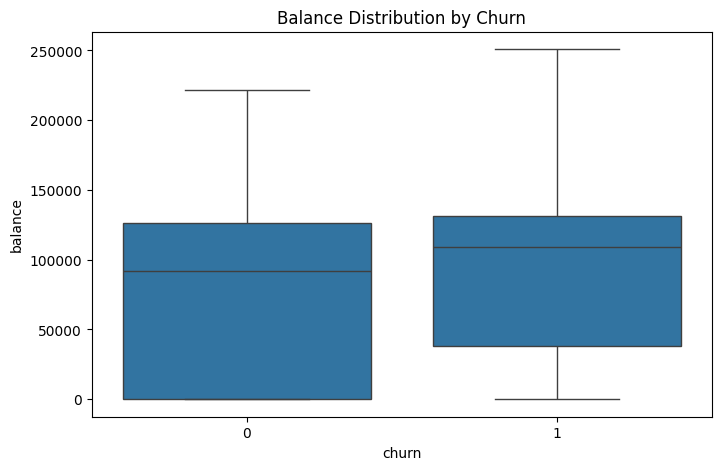

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='churn', y='balance', data=df)
plt.title('Balance Distribution by Churn')
plt.show()

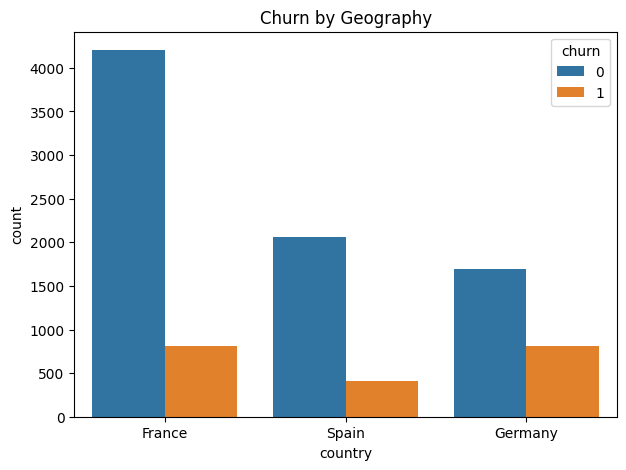

In [ ]:
plt.figure(figsize=(7,5))
sns.countplot(x='country', hue='churn', data=df)
plt.title('Churn by Geography')
plt.show()

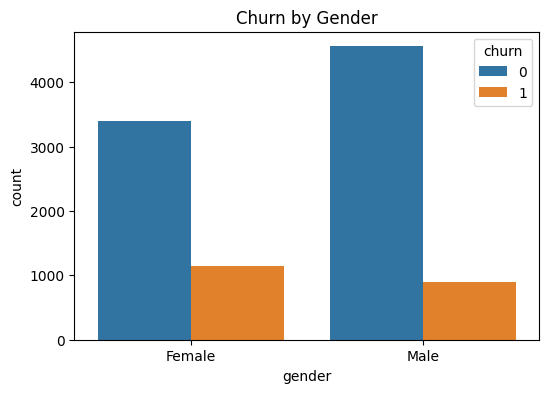

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='gender', hue='churn', data=df)
plt.title('Churn by Gender')
plt.show()

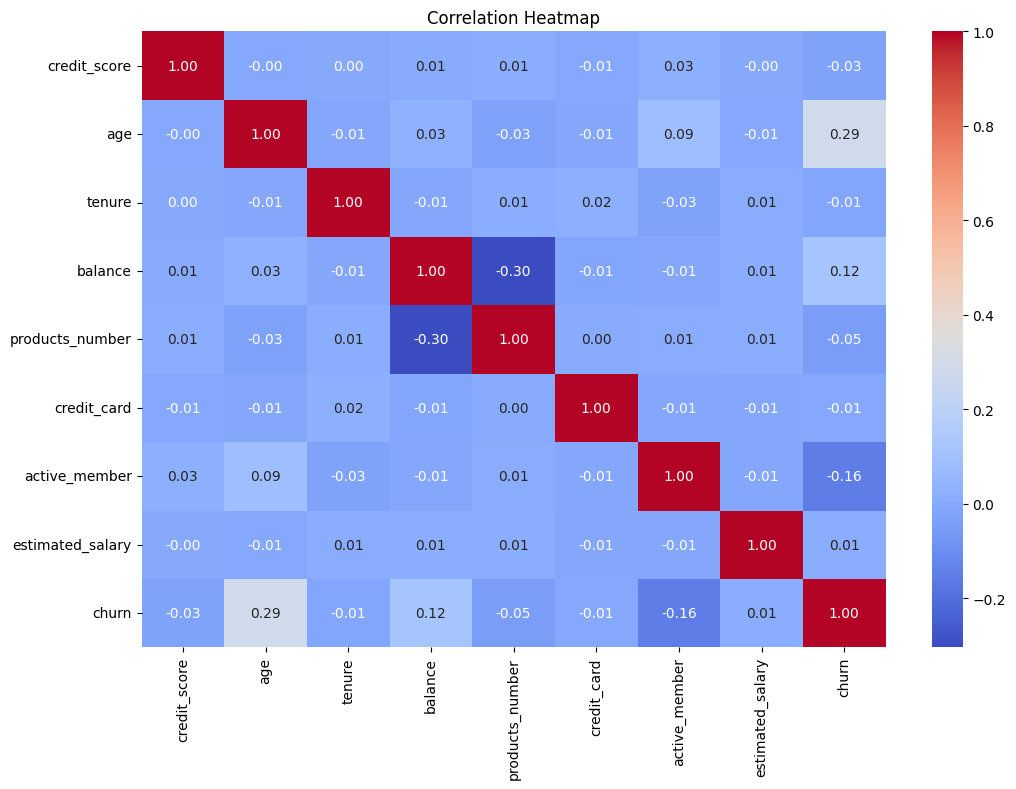

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.savefig('heatmap.png', bbox_inches='tight')
plt.show()

files.download('heatmap.png')

# Key Insights from EDA

- The dataset contains approximately 20.37% churned customers.
- Older customers appear more likely to leave the bank.
- Customers with higher account balances show a higher tendency to churn.
- Churn varies across different countries.
- Some features show stronger relationships with churn than others, particularly age, balance, and active_member.


# Data Preprocessing

In [ ]:
#Features
X = df.drop('churn', axis=1)

#Target
y = df['churn']

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
X.head()

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [ ]:
X = pd.get_dummies(X, columns=['country', 'gender'], drop_first=True)


In [ ]:
X.head()

,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,country_Germany,country_Spain,gender_Male
0,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,True,False


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

In [ ]:
print("Training Features: ", X_train.shape)
print("Testing Features: ", X_test.shape)

print("Training Labels: ", y_train.shape)
print("Testing Labels: ", y_test.shape)

Training Features:  (8000, 11)
Testing Features:  (2000, 11)
Training Labels:  (8000,)
Testing Labels:  (2000,)


In [ ]:
numeric_columns = [
    'credit_score',
    'age',
    'tenure',
    'balance',
    'products_number',
    'estimated_salary'
]

scaler = StandardScaler()

X_train[numeric_columns] = scaler.fit_transform(X_train[numeric_columns])
X_test[numeric_columns] = scaler.transform(X_test[numeric_columns])


In [ ]:
X_train.head()

,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,country_Germany,country_Spain,gender_Male
2151,1.058568,1.715086,0.684723,-1.226059,-0.910256,1,0,1.042084,False,False,True
8392,0.913626,-0.659935,-0.696202,0.413288,-0.910256,1,0,-0.623556,True,False,True
5006,1.079274,-0.184931,-1.731895,0.601687,0.808830,1,1,0.308128,True,False,False
4117,-0.929207,-0.184931,-0.005739,-1.226059,0.808830,1,0,-0.290199,False,False,True
7182,0.427035,0.955079,0.339492,0.548318,0.808830,0,1,0.135042,True,False,True


# Model 1: Logistic Regression

Predicts whether a customer is likely to churn (1) or remain with the bank (0).

In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(random_state=42)

log_model.fit(X_train, y_train)

LogisticRegression(random_state=42)

In [ ]:
y_pred = log_model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2%}")

Accuracy: 80.80%


In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



In [ ]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1540   53]
 [ 331   76]]


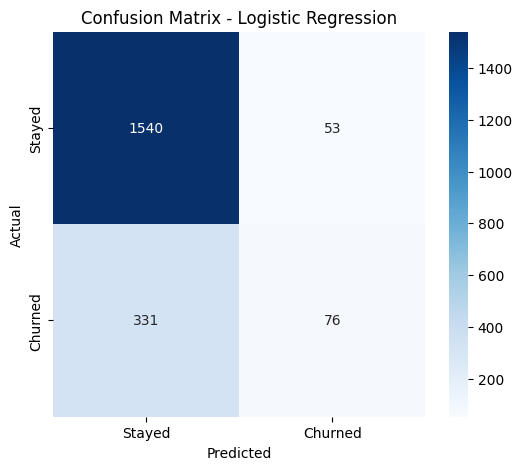

In [ ]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels = ['Stayed', 'Churned'],
    yticklabels = ['Stayed', 'Churned']
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("confusion_matrix_logistic.png", dpi=300, bbox_inches='tight')

plt.show()


In [ ]:
files.download('confusion_matrix_logistic.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Logistic Regression Results

The Logistic Regression model achieved an accuracy of 80.80%.

The confusion matrix shows how well the model distinguished between customers who stayed and customers who churned.

While the overall accuracy is high, additional metrics such as precision and recall are important because the dataset is imbalanced.

# Model 2: Decision Tree

In [ ]:
tree_model = DecisionTreeClassifier(random_state=42)

tree_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
tree_predictions = tree_model.predict(X_test)

In [ ]:
tree_accuracy = accuracy_score(y_test, tree_predictions)

print(f"Decision tree accuracy: {tree_accuracy:.2%}")

Decision tree accuracy: 78.25%


In [ ]:
print(classification_report(y_test, tree_predictions))

              precision    recall  f1-score   support

           0       0.87      0.85      0.86      1593
           1       0.47      0.51      0.49       407

    accuracy                           0.78      2000
   macro avg       0.67      0.68      0.68      2000
weighted avg       0.79      0.78      0.79      2000



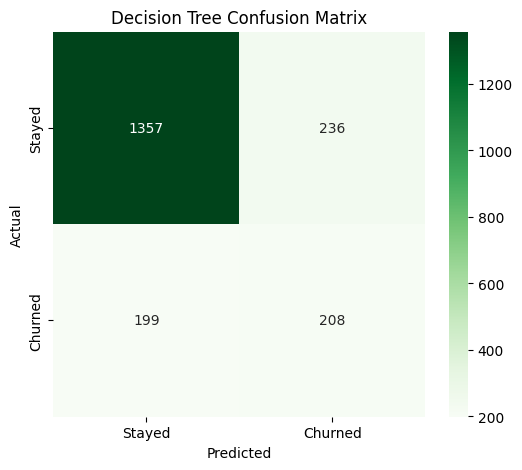

In [ ]:
tree_cm = confusion_matrix(y_test, tree_predictions)

plt.figure(figsize=(6,5))

sns.heatmap(
    tree_cm,
    annot = True,
    fmt = 'd',
    cmap = 'Greens',
    xticklabels = ['Stayed','Churned'],
    yticklabels = ['Stayed','Churned']
    )

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("confusion_matrix_tree.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
files.download("confusion_matrix_tree.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Model 3: Random Forest

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators = 100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
rf_predictions = rf_model.predict(X_test)

In [ ]:
rf_accuracy = accuracy_score(y_test, rf_predictions)

print(f"Random Forest Accuracy: {rf_accuracy:.2%}")

Random Forest Accuracy: 86.40%


In [ ]:
print(classification_report(y_test, rf_predictions))

              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.78      0.46      0.58       407

    accuracy                           0.86      2000
   macro avg       0.83      0.71      0.75      2000
weighted avg       0.86      0.86      0.85      2000



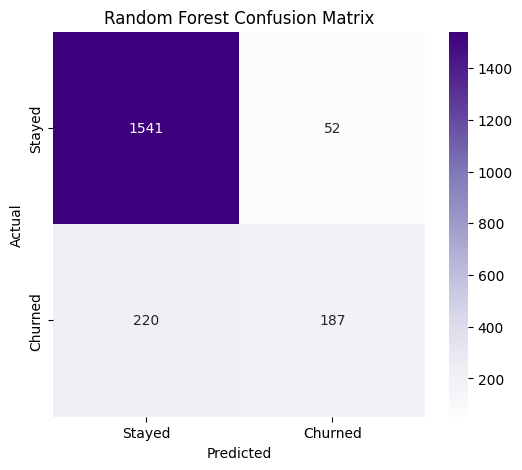

In [ ]:
rf_cm = confusion_matrix(y_test, rf_predictions)

plt.figure(figsize=(6,5))

sns.heatmap(
    rf_cm,
    annot = True,
    fmt = 'd',
    cmap = 'Purples',
    xticklabels = ['Stayed','Churned'],
    yticklabels = ['Stayed','Churned']
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("confusion_matrix_random_forest.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
files.download("confusion_matrix_random_forest.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
1,age,0.236485
7,estimated_salary,0.147016
0,credit_score,0.142756
3,balance,0.141756
4,products_number,0.130410
2,tenure,0.081817
6,active_member,0.039933
8,country_Germany,0.028923
5,credit_card,0.018799
10,gender_Male,0.018483


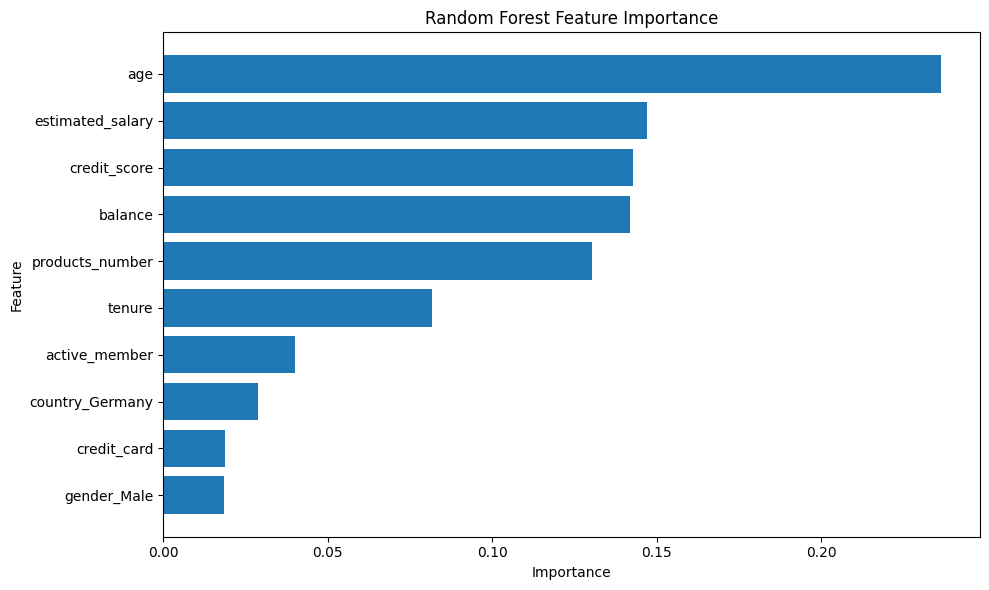

In [ ]:
top_features = feature_importance.head(10).sort_values(
    by='Importance',
    ascending=True
)
plt.figure(figsize=(10, 6))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Random Forest Feature Importance')

plt.tight_layout()

plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
feature_importance.to_csv("feature_importance.csv", index=False)
files.download("feature_importance.csv")
files.download('feature_importance.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Feature Importance Analysis

The Random Forest model identified age as the most influential factor in predicting customer churn.
This suggests that customer age plays a significant role in whether a customer
remains with or leaves the bank.

Other important factors included estimated salary, credit score, account
balance, and number of products, indicating that both customer demographics
and financial characteristics contribute to churn behaviour.

Features such as credit card ownership and gender had relatively low
importance, suggesting they have less influence on customer churn in this
dataset.

# Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

In [ ]:
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid= param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

In [ ]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20, None],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='f1')

In [ ]:
print(grid_search.best_params_)

{'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}


In [ ]:
print(grid_search.best_score_)

0.5827270902215215


In [ ]:
best_rf = grid_search.best_estimator_

In [ ]:
best_predictions = best_rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, best_predictions))

print(classification_report(y_test, best_predictions))

Accuracy: 0.8655
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.79      0.46      0.58       407

    accuracy                           0.87      2000
   macro avg       0.83      0.72      0.75      2000
weighted avg       0.86      0.87      0.85      2000



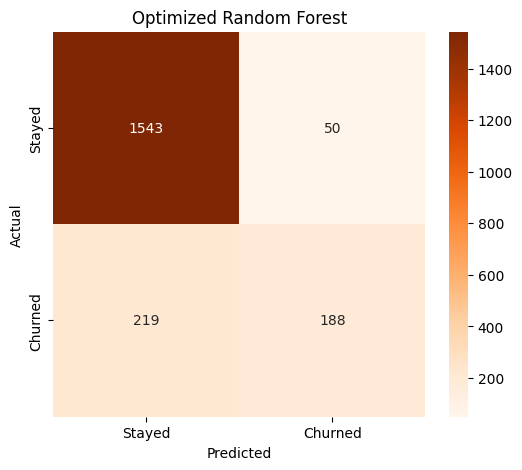

In [ ]:
best_cm = confusion_matrix(y_test, best_predictions)

plt.figure(figsize=(6,5))

sns.heatmap(
    best_cm,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=['Stayed','Churned'],
    yticklabels=['Stayed','Churned']
)

plt.title("Optimized Random Forest")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.savefig("optimized_random_forest.png", dpi=300)

plt.show()

# Model Evaluation

In [ ]:
from sklearn.metrics import roc_auc_score

y_prob = best_rf.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC: {roc_auc:.4f}")

ROC-AUC: 0.8581


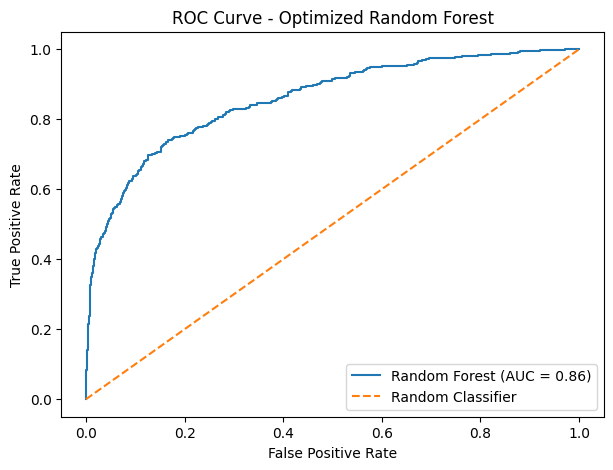

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f'Random Forest (AUC = {roc_auc:.2f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Optimized Random Forest')
plt.legend()

plt.savefig(
    'roc_curve.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [ ]:
files.download('roc_curve.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

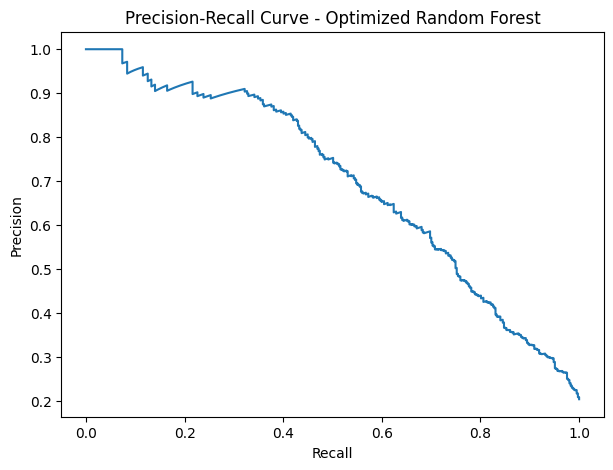

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(7,5))

plt.plot(
    recall,
    precision
)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Optimized Random Forest')

plt.savefig(
    'precision_recall_curve.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [ ]:
files.download('precision_recall_curve.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Model Evaluation Using ROC-AUC and Precision-Recall

ROC-AUC was used to evaluate how effectively the optimized Random Forest
distinguishes between customers who churn and customers who remain with the bank.

The Precision-Recall curve was also examined because the dataset contains an
imbalanced target variable, with approximately 20.37% of customers having churned.

These metrics provide additional insight beyond accuracy and help assess the
model's ability to identify customers at risk of churn.

# Model Comparison

In [ ]:
model_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'Optimized Random Forest'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, tree_predictions),
        accuracy_score(y_test, rf_predictions),
        accuracy_score(y_test, best_predictions)
    ],
    'Precision': [
        classification_report(y_test, y_pred, output_dict=True)['1']['precision'],
        classification_report(y_test, tree_predictions, output_dict=True)['1']['precision'],
        classification_report(y_test, rf_predictions, output_dict=True)['1']['precision'],
        classification_report(y_test, best_predictions, output_dict=True)['1']['precision']
    ],
    'Recall': [
        classification_report(y_test, y_pred, output_dict=True)['1']['recall'],
        classification_report(y_test, tree_predictions, output_dict=True)['1']['recall'],
        classification_report(y_test, rf_predictions, output_dict=True)['1']['recall'],
        classification_report(y_test, best_predictions, output_dict=True)['1']['recall']
    ],
    'F1 Score': [
        classification_report(y_test, y_pred, output_dict=True)['1']['f1-score'],
        classification_report(y_test, tree_predictions, output_dict=True)['1']['f1-score'],
        classification_report(y_test, rf_predictions, output_dict=True)['1']['f1-score'],
        classification_report(y_test, best_predictions, output_dict=True)['1']['f1-score']
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8080,0.589147,0.186732,0.283582
1,Decision Tree,0.7825,0.468468,0.511057,0.488837
2,Random Forest,0.8640,0.782427,0.459459,0.578947
3,Optimized Random Forest,0.8655,0.789916,0.461916,0.582946


In [ ]:
comparison_display = model_comparison.copy()

for column in ['Accuracy', 'Precision', 'Recall', 'F1 Score']:
    comparison_display[column] = (
        comparison_display[column] * 100
    ).round(2).astype(str) + '%'

comparison_display

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,80.8%,58.91%,18.67%,28.36%
1,Decision Tree,78.25%,46.85%,51.11%,48.88%
2,Random Forest,86.4%,78.24%,45.95%,57.89%
3,Optimized Random Forest,86.55%,78.99%,46.19%,58.29%


In [ ]:
model_comparison.to_csv(
    'model_comparison.csv',
    index=False
)

files.download('model_comparison.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

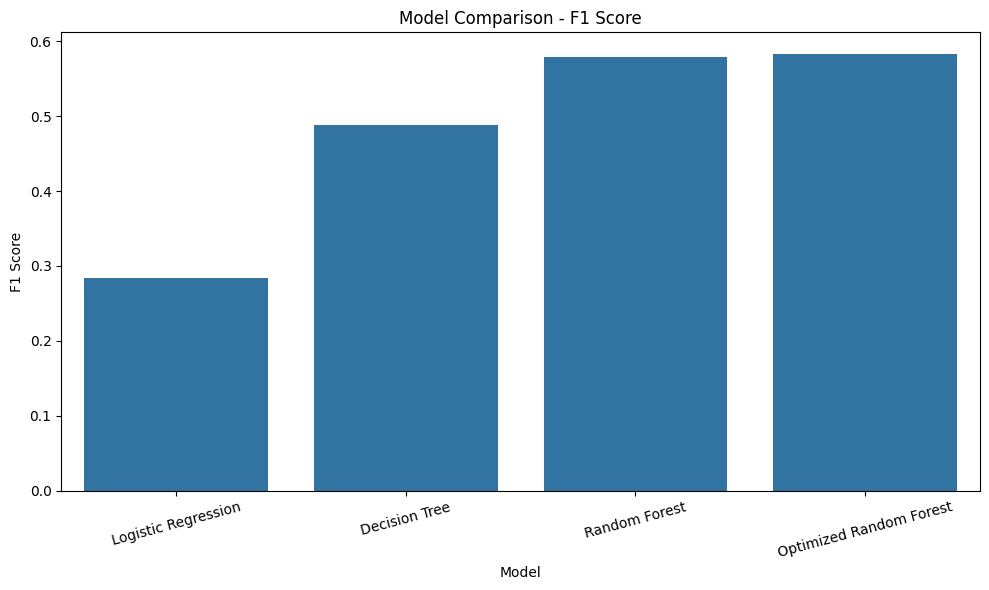

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=model_comparison,
    x='Model',
    y='F1 Score'
)

plt.title('Model Comparison - F1 Score')
plt.xlabel('Model')
plt.ylabel('F1 Score')
plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    'model_comparison_f1.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [ ]:
files.download('model_comparison_f1.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Final Model Selection

Four classification models were evaluated: Logistic Regression, Decision Tree,
Random Forest, and an optimized Random Forest.

The optimized Random Forest achieved the highest overall accuracy at 86.55%
and a ROC-AUC score of 0.8581. It also achieved a churn precision of 79% and
an F1-score of approximately 58%.

Although hyperparameter tuning resulted in only a modest improvement over the
original Random Forest, the optimized model provided the strongest overall
performance and was therefore selected as the final model.

However, the recall for churn remained at approximately 46%, meaning that the
model does not identify all customers who eventually churn. Therefore, the
model should be used as a decision-support tool rather than as the sole basis
for customer retention decisions.

#Business Recommendations

Based on the exploratory analysis and model results, the following
recommendations can be made:

1. The bank could use the predicted churn probabilities to identify which customers need to be prioritized.

2. Further analysis could be used to understand why certain demographic or account groups have higher churn rates.

3. High-risk customers could receive personalized offers, support or engagement before they decide to leave.

4. Customer behaviour can change over time, so the model should be evaluated regularly and retrained when its performance begins to decline.

# Project Limitations

- The dataset contains a limited set of customer attributes and may not
capture all factors influencing churn.

- The dataset is imbalanced, with approximately 20.37% of customers classified
as churned.

- The optimized Random Forest achieved a recall of approximately 46% for
churned customers, meaning that a significant proportion of actual churners
were not identified.

- Feature importance indicates which variables contributed to the model's
predictions but does not establish causation.

- The model was evaluated using historical data and may require retraining when
customer behaviour changes.

- The dataset is a static dataset, so the project does not demonstrate how the
model would perform on continuously changing production data.

# Conclusion

This project demonstrated how machine learning can be applied to customer
churn prediction in a banking context.

Four classification approaches were evaluated, with the optimized Random
Forest providing the strongest overall performance. The model achieved 86.55%
accuracy and a ROC-AUC of 0.8581, while achieving 79% precision and 46% recall
for customers who churned.

The analysis also identified age, estimated salary, credit score, balance and
number of products as some of the most influential features in the model.

Although the model demonstrates useful predictive performance, the relatively
low recall for churn indicates that further improvements could be explored.
Future work could include testing additional algorithms, addressing class
imbalance, optimizing the classification threshold and evaluating the model on
newer customer data.

Overall, the project demonstrates the use of exploratory data analysis, data
preprocessing, classification, model evaluation, hyperparameter tuning and
business interpretation to address a practical banking problem.